#### EDA - Análise Exploratória de Dados (EDA) 

1. Setup e carga do arquivo

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# Leia o CSV (usa ; ou , conforme seu arquivo)
# update file path
df = pd.read_csv("../data/Moto_HW_DATA_hashed.csv")   

# Se quiser trabalhar só com as colunas de interesse
cols = [
    "full_cap_min", "btlow_total", "dchrg_diff", "total_chrg_cnt",
    "son_hrs", "msgs_tot", "wifi_hrs", "mobile_rx_MB"
]
df = df[cols]

2. Criação de rótulo de ineficiência

label_ineficiente
1    0.52794
0    0.47206
Name: proportion, dtype: float64


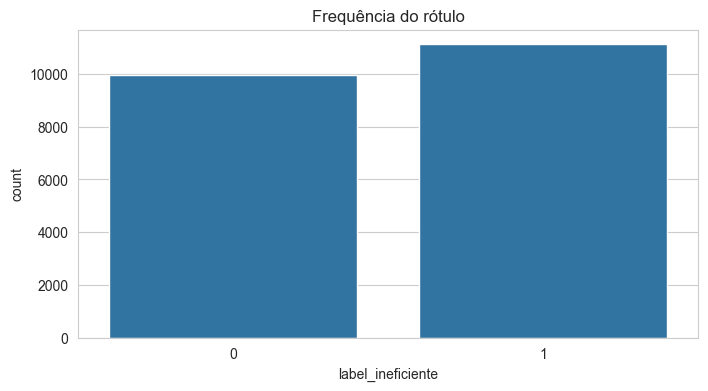

In [2]:
def make_label(row):
    return int(
        (row["dchrg_diff"] > 25)
        and ((row["full_cap_min"] < 2800) or (row["btlow_total"] > 10))
    )

df["label_ineficiente"] = df.apply(make_label, axis=1)

# Distribuição do alvo
print(df["label_ineficiente"].value_counts(normalize=True))
sns.countplot(x="label_ineficiente", data=df)
plt.title("Frequência do rótulo")
plt.show()

3. Visão geral

In [3]:
# display(df.head())
df.info()
df.describe().T   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21063 entries, 0 to 21062
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   full_cap_min       21063 non-null  float64
 1   btlow_total        21063 non-null  float64
 2   dchrg_diff         21063 non-null  float64
 3   total_chrg_cnt     21063 non-null  float64
 4   son_hrs            21063 non-null  float64
 5   msgs_tot           11386 non-null  float64
 6   wifi_hrs           21063 non-null  float64
 7   mobile_rx_MB       21063 non-null  float64
 8   label_ineficiente  21063 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.4 MB


,count,mean,std,min,25%,50%,75%,max
full_cap_min,21063.0,333131.836940,1.105046e+06,-1.0,-1.00,-1.00,4869.875,5081000.00
btlow_total,21063.0,23.399789,7.808618e+02,0.0,1.00,1.25,2.250,107014.00
dchrg_diff,21063.0,71.769253,3.799376e+01,0.0,45.25,67.00,92.000,721.00
total_chrg_cnt,21063.0,7.128694,1.301778e+01,0.0,2.00,3.50,7.000,347.50
son_hrs,21063.0,5.205605,2.769159e+00,0.0,3.00,5.00,7.000,21.00
msgs_tot,11386.0,96.929668,1.249211e+02,1.0,29.25,64.50,121.000,4533.00
wifi_hrs,21063.0,12.355275,1.837340e+01,0.0,2.00,7.00,21.000,752.00
mobile_rx_MB,21063.0,108.330611,2.660867e+02,0.0,0.00,0.00,104.250,7014.25
label_ineficiente,21063.0,0.527940,4.992306e-01,0.0,0.00,1.00,1.000,1.00


In [4]:
na = df.isna().sum().sort_values(ascending=False)
display(na[na > 0])   

msgs_tot    9677
dtype: int64